# IOT_Based_Crop_Disease_Detection_System_For_Smart_Agriculture


### Import packages

In [1]:
# ================================
# Standard Library
# ================================
import os
import json
import time

# ================================
# Numerical Computing
# ================================
import numpy as np
import pandas as pd

# ================================
# Visualization
# ================================
import matplotlib.pyplot as plt

# ================================
# PyTorch
# ================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# ================================
# Torchvision
# ================================
import torchvision
from torchvision import datasets, transforms, models

# ================================
# Progress Bar
# ================================
from tqdm.auto import tqdm

# ================================
# Evaluation Metrics
# ================================
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

### Check GPU / CPU

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Import Datast

### Mount Google Drive

In [3]:
from google.colab import drive # type: ignore
drive.mount('/content/drive')

Mounted at /content/drive


### Load Train , Valid , Test 

In [4]:
from torchvision import datasets, transforms

In [5]:
# Define preprocessing and augmentation

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        size=224,
        scale=(0.9, 1.0)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = valid_transform

In [6]:
base_path = "/content/drive/MyDrive/dataset/Crop_Disease_Split"

print(os.listdir(base_path))

['test', 'train', 'valid']


In [7]:
train_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/dataset/Crop_Disease_Split/train",
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/dataset/Crop_Disease_Split/valid",
    transform=valid_transform
)

test_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/dataset/Crop_Disease_Split/test",
    transform=test_transform
)

### train_transform 
- The training transform takes a raw JPG/JPEG RGB image, applies random data augmentation (crop, flip, and rotation), converts it into a normalized float32 PyTorch tensor of shape (3, 224, 224), and prepares it as input for EfficientNet-B0 during model training.

In [8]:
# Train DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Validation DataLoader
valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("=" * 50)
print("Train Images      :", len(train_dataset))
print("Validation Images :", len(valid_dataset))
print("Test Images       :", len(test_dataset))
print("=" * 50)
print("Train Batches     :", len(train_loader))
print("Validation Batches:", len(valid_loader))
print("Test Batches      :", len(test_loader))
print("=" * 50)

Train Images      : 15512
Validation Images : 3325
Test Images       : 3332
Train Batches     : 485
Validation Batches: 104
Test Batches      : 105


### Load the  EfficientNet-B0 model

In [9]:
# Number of classes
NUM_CLASSES = 19

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Replace the final classifier
model.classifier[1] = nn.Linear(
    in_features=model.classifier[1].in_features,
    out_features=NUM_CLASSES
)

# Select device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model = model.to(device)

# Print model information
print(model)
print("\nOutput classes:", model.classifier[1].out_features)
print("Device:", device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 146MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [10]:
# Loss Function
criterion = nn.CrossEntropyLoss()

In [11]:
# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [12]:
# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=3
)

In [13]:
# Create folder if it doesn't exist
save_dir = "/content/drive/MyDrive/Trained_Models"
os.makedirs(save_dir, exist_ok=True)

# Best model save path
model_path = os.path.join(save_dir, "efficientnet_b0_best.pth")

print("=" * 50)
print(f"Best model will be saved at:\n{model_path}")
print("=" * 50)

Best model will be saved at:
/content/drive/MyDrive/Trained_Models/efficientnet_b0_best.pth


In [14]:
# Number of training epochs
num_epochs = 10

# Best validation accuracy
best_val_acc = 0.0

for epoch in range(num_epochs):

    start_time = time.time()

    # =========================
    # Training
    # =========================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{num_epochs}",
        unit="batch"
    )

    for batch_idx, (images, labels) in enumerate(progress_bar):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        current_loss = running_loss / (batch_idx + 1)
        current_accuracy = 100 * correct / total

        progress_bar.set_postfix(
            Loss=f"{current_loss:.4f}",
            Accuracy=f"{current_accuracy:.2f}%"
        )

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    # =========================
    # Validation
    # =========================
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = 100 * val_correct / val_total

    # Update scheduler using validation loss
    scheduler.step(val_loss)

    # Save best model
    if val_accuracy > best_val_acc:

        best_val_acc = val_accuracy

        torch.save(model.state_dict(), model_path)

        print("\nBest model saved!")

    epoch_time = time.time() - start_time

    print("\n" + "=" * 60)
    print(f"Epoch {epoch+1}/{num_epochs} Completed")
    print(f"Training Loss      : {epoch_loss:.4f}")
    print(f"Training Accuracy  : {epoch_accuracy:.2f}%")
    print(f"Validation Loss    : {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")
    print(f"Best Validation Acc: {best_val_acc:.2f}%")
    print(f"Epoch Time         : {epoch_time:.2f} sec")
    print("=" * 60)

Epoch 1/10:   0%|          | 0/485 [00:00<?, ?batch/s]


Best model saved!

Epoch 1/10 Completed
Training Loss      : 0.4056
Training Accuracy  : 85.93%
Validation Loss    : 0.2598
Validation Accuracy: 90.44%
Best Validation Acc: 90.44%
Epoch Time         : 3735.47 sec


Epoch 2/10:   0%|          | 0/485 [00:00<?, ?batch/s]


Best model saved!

Epoch 2/10 Completed
Training Loss      : 0.2409
Training Accuracy  : 91.25%
Validation Loss    : 0.2398
Validation Accuracy: 91.52%
Best Validation Acc: 91.52%
Epoch Time         : 155.21 sec


Epoch 3/10:   0%|          | 0/485 [00:00<?, ?batch/s]

...

Epoch 9/10:   0%|          | 0/485 [00:00<?, ?batch/s]


Epoch 9/10 Completed
Training Loss      : 0.1165
Training Accuracy  : 96.09%
Validation Loss    : 0.1475
Validation Accuracy: 95.34%
Best Validation Acc: 95.64%
Epoch Time         : 159.36 sec


Epoch 10/10:   0%|          | 0/485 [00:00<?, ?batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e8c26094720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e8c26094720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


Epoch 10/10 Completed
Training Loss      : 0.1217
Training Accuracy  : 95.77%
Validation Loss    : 0.2373
Validation Accuracy: 94.80%
Best Validation Acc: 95.64%
Epoch Time         : 161.71 sec


In [15]:
# Evaluate on Test Dataset

# Load the best saved model
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss /= len(test_loader)
test_accuracy = 100 * correct / total

print("=" * 50)
print("Best Model Evaluation")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.2f}%")
print("=" * 50)

Best Model Evaluation
Test Loss     : 0.1515
Test Accuracy : 95.47%


In [16]:
# Classification Report

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

report = classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes,
    digits=4
)

print("=" * 80)
print("Classification Report")
print("=" * 80)
print(report)

# Save report
report_path = os.path.join(save_dir, "classification_report.txt")

with open(report_path, "w") as f:
    f.write(report)

print("=" * 50)
print("Classification report saved successfully!")
print(f"Location: {report_path}")
print("=" * 50)

Classification Report
                                            precision    recall  f1-score   support

                Corn_(Maize)___Common_Rust     1.0000    1.0000    1.0000       179
Corn_(Maize)___Gray_Leaf_Spot_(Cercospora)     0.9846    0.8312    0.9014        77
                    Corn_(Maize)___Healthy     0.9777    1.0000    0.9887       175
                  Corn_(Maize)___Leaf_Spot     0.8303    0.9526    0.8873       190
         Corn_(Maize)___Maize_Streak_Virus     0.9200    0.7616    0.8333       151
       Corn_(Maize)___Northern_Leaf_Blight     0.9068    0.9865    0.9450       148
                     Potato___Early_Blight     1.0000    0.9933    0.9967       150
                          Potato___Healthy     0.9932    1.0000    0.9966       146
                      Potato___Late_Blight     1.0000    0.9933    0.9967       150
                         Rice___Brown_Spot     0.8446    0.8956    0.8693       182
                            Rice___Healthy     0.8659

Confusion Matrix saved successfully!
Location: /content/drive/MyDrive/Trained_Models/confusion_matrix.png


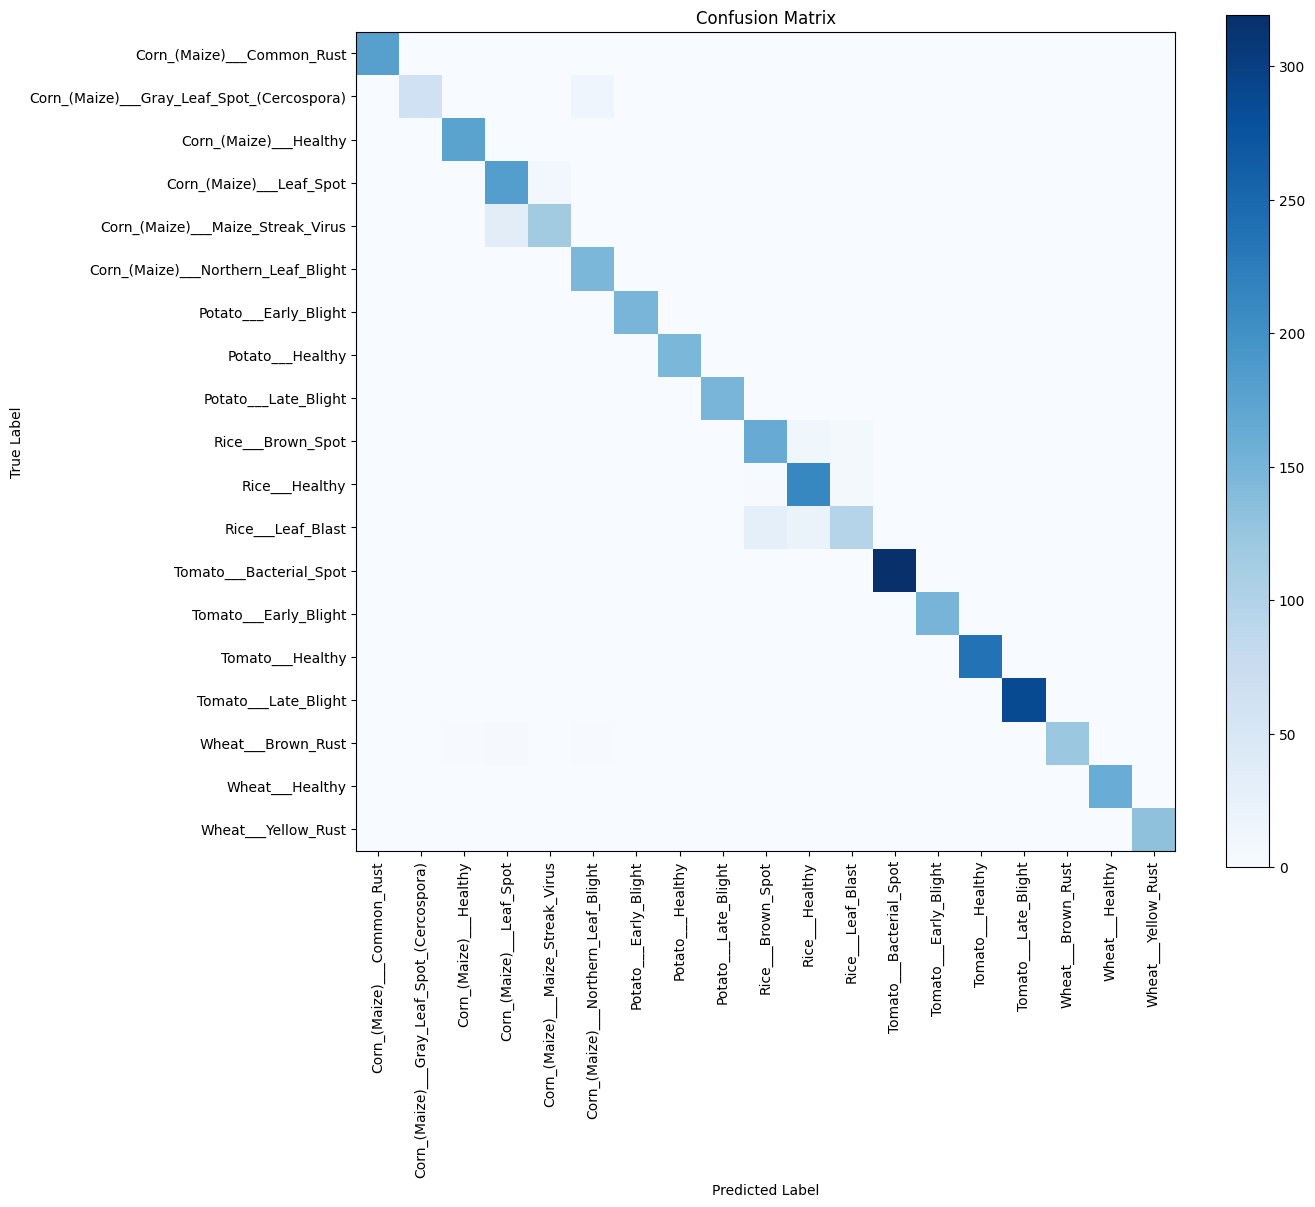

In [17]:
# Confusion Matrix

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(14, 12))

plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(train_dataset.classes))

plt.xticks(tick_marks, train_dataset.classes, rotation=90)
plt.yticks(tick_marks, train_dataset.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

# Save confusion matrix
cm_path = os.path.join(save_dir, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")

print("=" * 50)
print("Confusion Matrix saved successfully!")
print(f"Location: {cm_path}")
print("=" * 50)

plt.show()

In [18]:
# Save Class Names

# Create folder if it doesn't exist
save_dir = "/content/drive/MyDrive/Trained_Models"
os.makedirs(save_dir, exist_ok=True)

# Save class names
class_path = os.path.join(save_dir, "class_names.json")

with open(class_path, "w") as f:
    json.dump(train_dataset.classes, f, indent=4)

print("=" * 50)
print("Class names saved successfully!")
print(f"Saved at: {class_path}")
print("=" * 50)

Class names saved successfully!
Saved at: /content/drive/MyDrive/Trained_Models/class_names.json
